
# ASUM-DM — Demo controlada en Jupyter Lab (Retail, reposiciones **top-k**)

Este cuaderno guía un flujo **end-to-end** basado en ASUM-DM para una cadena de supermercados que desea priorizar **top-k** tienda–SKU por semana para reabastecimiento.  
Se usan datos **sintéticos** para que el estudiante practique sin depender de fuentes externas.

> **Fases ASUM-DM cubiertas**  
> **Analyze:** objetivo y criterio de éxito.  
> **Design:** reglas anti-leakage, validación temporal, contratos (simulados).  
> **Configure & Build:** preparación y generación de variables.  
> **Deploy (simulado):** lista `top-k` por tienda–SKU para la última semana.  
> **Operate & Optimize (mini):** chequeo simple de drift y reporte de salud.



## 1) Analyze — Objetivo, criterio de éxito y punto de decisión

- **Problema:** rotura de stock en góndola reduce ventas en ~500 SKU críticos.
- **Decisión operativa:** cada lunes 07:00 generar **lista top-k=200** tienda–SKU a intervenir.
- **KPI negocio (éxito):** % disponibilidad y **ventas recuperadas** frente a línea base.
- **Lectura operativa:** concentración de ventas en el **top-k** recomendado.
- **Métrica técnica:** AUC/PR-AUC del ranking de riesgo de quiebre.
- **Política de uso:** no recomendar > stock en bodega; respetar presupuesto por tienda.



## 2) Design — Reglas y validación

- **Corte temporal / anti-leakage:** todas las features para la semana *t* usan solo información ≤ *t-1*.
- **Validación:** split temporal — entrenamiento hasta `semana <= T-4`, validación `T-3..T-1`, prueba `T`.
- **Artefactos:** diccionario de datos, esquema de partición, *blueprint* de pipeline (simulados aquí).


In [1]:

# 3) Librerías e hiperparámetros
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

np.random.seed(42)

CFG = {
    "n_stores": 40,
    "n_skus": 300,
    "n_weeks": 60,      # ~14 meses
    "top_k": 200        # capacidad operativa semanal
}
CFG


{'n_stores': 40, 'n_skus': 300, 'n_weeks': 60, 'top_k': 200}


## 3) Configure & Build — Generación de datos sintéticos
Creamos ventas semanales por tienda–SKU con estacionalidad, promos y clima.  
Definimos un **objetivo** binario de *riesgo de quiebre* para la siguiente semana.


In [2]:

rng = np.random.default_rng(42)

stores = [f"S{str(i).zfill(2)}" for i in range(CFG["n_stores"])]
skus   = [f"K{str(i).zfill(3)}" for i in range(CFG["n_skus"])]
weeks  = pd.date_range("2023-01-02", periods=CFG["n_weeks"], freq="W-MON")  # lunes

rows = []
for w, week in enumerate(weeks):
    season = 1.0 + 0.2*np.sin(2*np.pi*w/52)
    for s in stores:
        city_temp = 20 + 10*np.sin(2*np.pi*(w+hash(s)%7)/52) + rng.normal(0,2)
        for k in skus:
            base = 10 + 5*np.sin(2*np.pi*(w+hash(k)%19)/26)
            promo = rng.random() < 0.15
            price = 1.0 + 0.3*rng.normal()
            stock = max(0, int(rng.normal(60, 20)))
            demand = max(0, int(season*base*(1.2 if promo else 1.0)*max(0.5, (1.3 - 0.1*price)) + rng.normal(0,3)))
            sales = min(stock, demand)
            risk_latent = (stock < 25) * 1.0 + (demand > 15) * 0.7 + (promo)*0.2
            rows.append([week, s, k, promo, price, stock, demand, sales, city_temp, risk_latent])

df = pd.DataFrame(rows, columns=["week","store","sku","promo","price","stock","demand","sales","temp","risk_latent"])
df.head()


,week,store,sku,promo,price,stock,demand,sales,temp,risk_latent
0,2023-01-02,S00,K000,False,1.225135,78,8,8,20.609434,0.0
1,2023-01-02,S00,K001,False,1.038352,53,17,17,20.609434,0.7
2,2023-01-02,S00,K002,False,1.263819,75,8,8,20.609434,0.0
3,2023-01-02,S00,K003,False,1.140253,42,9,9,20.609434,0.0
4,2023-01-02,S00,K004,True,1.263535,59,16,16,20.609434,0.9



## 4) Configure & Build — Ingeniería de variables **sin fuga de información**
Target: quiebre en *t+1*; features con lags y promedios móviles hasta *t*.


In [3]:

df_sorted = df.sort_values(["store","sku","week"]).reset_index(drop=True)
df_sorted["sales_next"] = df_sorted.groupby(["store","sku"])["sales"].shift(-1)
df_sorted["stock_next"] = df_sorted.groupby(["store","sku"])["stock"].shift(-1)
df_sorted["demand_next"] = df_sorted.groupby(["store","sku"])["demand"].shift(-1)

df_sorted["break_next"] = ((df_sorted["sales_next"] < df_sorted["demand_next"]) & (df_sorted["stock_next"]==0)).astype(int)

for col in ["sales","stock","demand","promo"]:
    df_sorted[f"{col}_lag1"] = df_sorted.groupby(["store","sku"])[col].shift(1)
    df_sorted[f"{col}_lag2"] = df_sorted.groupby(["store","sku"])[col].shift(2)

df_sorted["promo_rolling4"] = df_sorted.groupby(["store","sku"])["promo"].shift(1).rolling(4).mean()
df_sorted["sales_ma4"] = df_sorted.groupby(["store","sku"])["sales"].shift(1).rolling(4).mean()
df_sorted["stock_ma4"] = df_sorted.groupby(["store","sku"])["stock"].shift(1).rolling(4).mean()

feat_cols = ["price","temp","promo","sales_lag1","sales_lag2","stock_lag1","stock_lag2",
             "demand_lag1","demand_lag2","promo_rolling4","sales_ma4","stock_ma4"]
data = df_sorted.dropna(subset=feat_cols + ["break_next"]).copy()
data.head()


,week,store,sku,promo,price,stock,demand,sales,temp,risk_latent,...,sales_lag2,stock_lag1,stock_lag2,demand_lag1,demand_lag2,promo_lag1,promo_lag2,promo_rolling4,sales_ma4,stock_ma4
4,2023-01-30,S00,K000,True,1.139942,62,19,19,25.963679,0.9,...,19.0,60.0,47.0,20.0,19.0,False,False,0.00,15.00,64.00
5,2023-02-06,S00,K000,False,0.654013,44,18,18,24.977279,0.7,...,20.0,62.0,60.0,19.0,20.0,True,False,0.25,17.75,60.00
6,2023-02-13,S00,K000,True,0.711365,70,26,26,28.301717,0.9,...,19.0,44.0,62.0,18.0,19.0,False,True,0.25,19.00,53.25
7,2023-02-20,S00,K000,False,1.250652,114,21,21,25.160587,0.7,...,18.0,70.0,44.0,26.0,18.0,True,False,0.50,20.75,59.00
8,2023-02-27,S00,K000,False,0.781421,31,14,14,24.968910,0.0,...,26.0,114.0,70.0,21.0,26.0,False,True,0.50,21.00,72.50



## 5) Design — División temporal (train/val/test)
Entrenamiento hasta `T-4`, validación `T-3..T-1`, prueba `T`.


In [4]:

T = data["week"].max()

train = data[data["week"] <= data["week"].unique()[-4]]
val   = data[(data["week"] > data["week"].unique()[-4]) & (data["week"] < T)]
test  = data[data["week"] == T]

X_train, y_train = train[feat_cols], train["break_next"]
X_val, y_val     = val[feat_cols], val["break_next"]
X_test, y_test   = test[feat_cols], test["break_next"]

len(train), len(val), len(test), T


(636000, 24000, 12000, Timestamp('2024-02-19 00:00:00'))


## 6) Configure & Build — Entrenamiento


In [5]:

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe.fit(X_train, y_train)

val_scores = pipe.predict_proba(X_val)[:,1]
from sklearn.metrics import roc_auc_score, average_precision_score
auc_val = roc_auc_score(y_val, val_scores)
ap_val  = average_precision_score(y_val, val_scores)
auc_val, ap_val


(0.4850234190893336, 0.0020352328262577516)


## 7) Evaluación — top-k


In [6]:

def topk_capture(y_true, y_score, k):
    order = np.argsort(-y_score)
    y_true = np.array(y_true)[order]
    return y_true[:k].sum()

test_scores = pipe.predict_proba(X_test)[:,1]
k = CFG["top_k"]
capture = topk_capture(y_test, test_scores, k)
total_breaks = int(y_test.sum())

print(f"ROC-AUC (val): {auc_val:.3f} | AP (val): {ap_val:.3f}")
print(f"Quiebres reales en semana T: {total_breaks}")
print(f"Quiebres capturados en top-{k}: {int(capture)} "
      f"({100*capture/max(1,total_breaks):.1f}% de los quiebres)")


ROC-AUC (val): 0.485 | AP (val): 0.002
Quiebres reales en semana T: 0
Quiebres capturados en top-200: 0 (0.0% de los quiebres)



## 8) Deploy (simulado) — Exportación de lista top-k


In [7]:

test_out = test[["week","store","sku"]].copy()
test_out["score"] = test_scores
topk = test_out.sort_values("score", ascending=False).head(k)
out_path = "topk_reposicion.csv"
topk[["store","sku","score","week"]].to_csv(out_path, index=False)
out_path


'topk_reposicion.csv'


## 9) Operate & Optimize — Chequeo simple de drift


In [8]:

def sed(a, b):
    return (a.mean() - b.mean()) / np.sqrt(0.5*(a.var()+b.var()) + 1e-9)

import pandas as pd
drift_report = []
for col in feat_cols:
    sed_val = sed(val[col], test[col])
    drift_report.append((col, float(sed_val)))
drift_df = pd.DataFrame(drift_report, columns=["feature","SED_val_vs_test"]).sort_values("SED_val_vs_test")
drift_path = "drift_report.csv"
drift_df.to_csv(drift_path, index=False)
drift_path


'drift_report.csv'


### Visualización: distribución de `score` en validación vs prueba


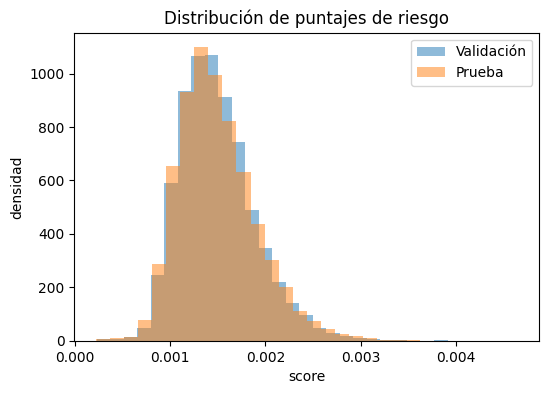

In [9]:

plt.figure(figsize=(6,4))
plt.hist(val_scores, bins=30, alpha=0.5, label="Validación", density=True)
plt.hist(test_scores, bins=30, alpha=0.5, label="Prueba", density=True)
plt.title("Distribución de puntajes de riesgo")
plt.xlabel("score")
plt.ylabel("densidad")
plt.legend()
plt.show()
